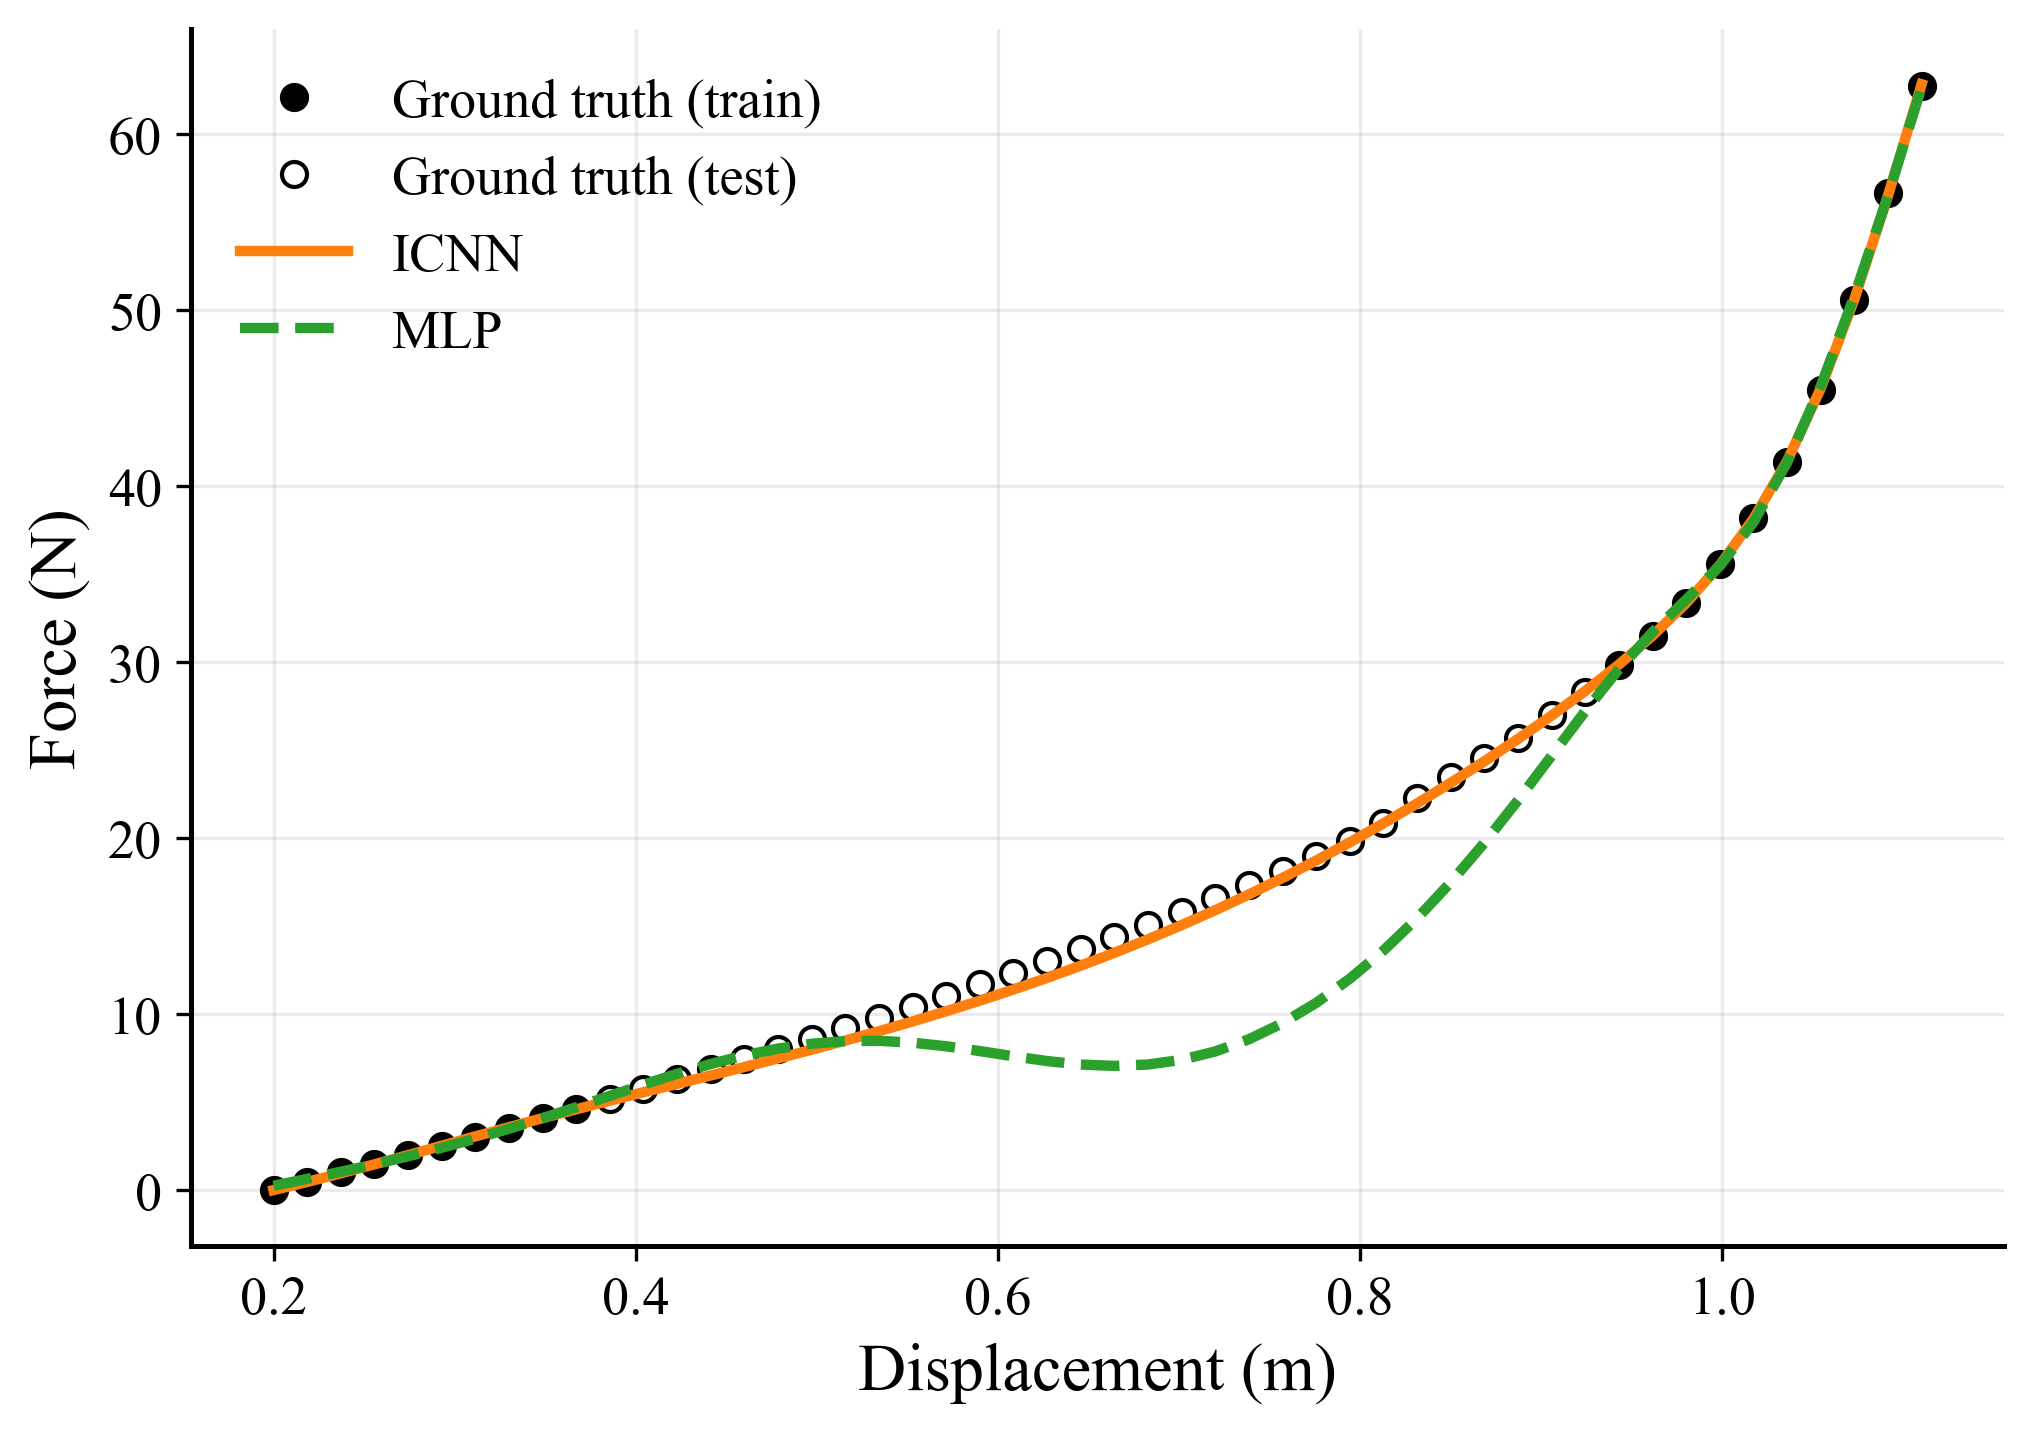

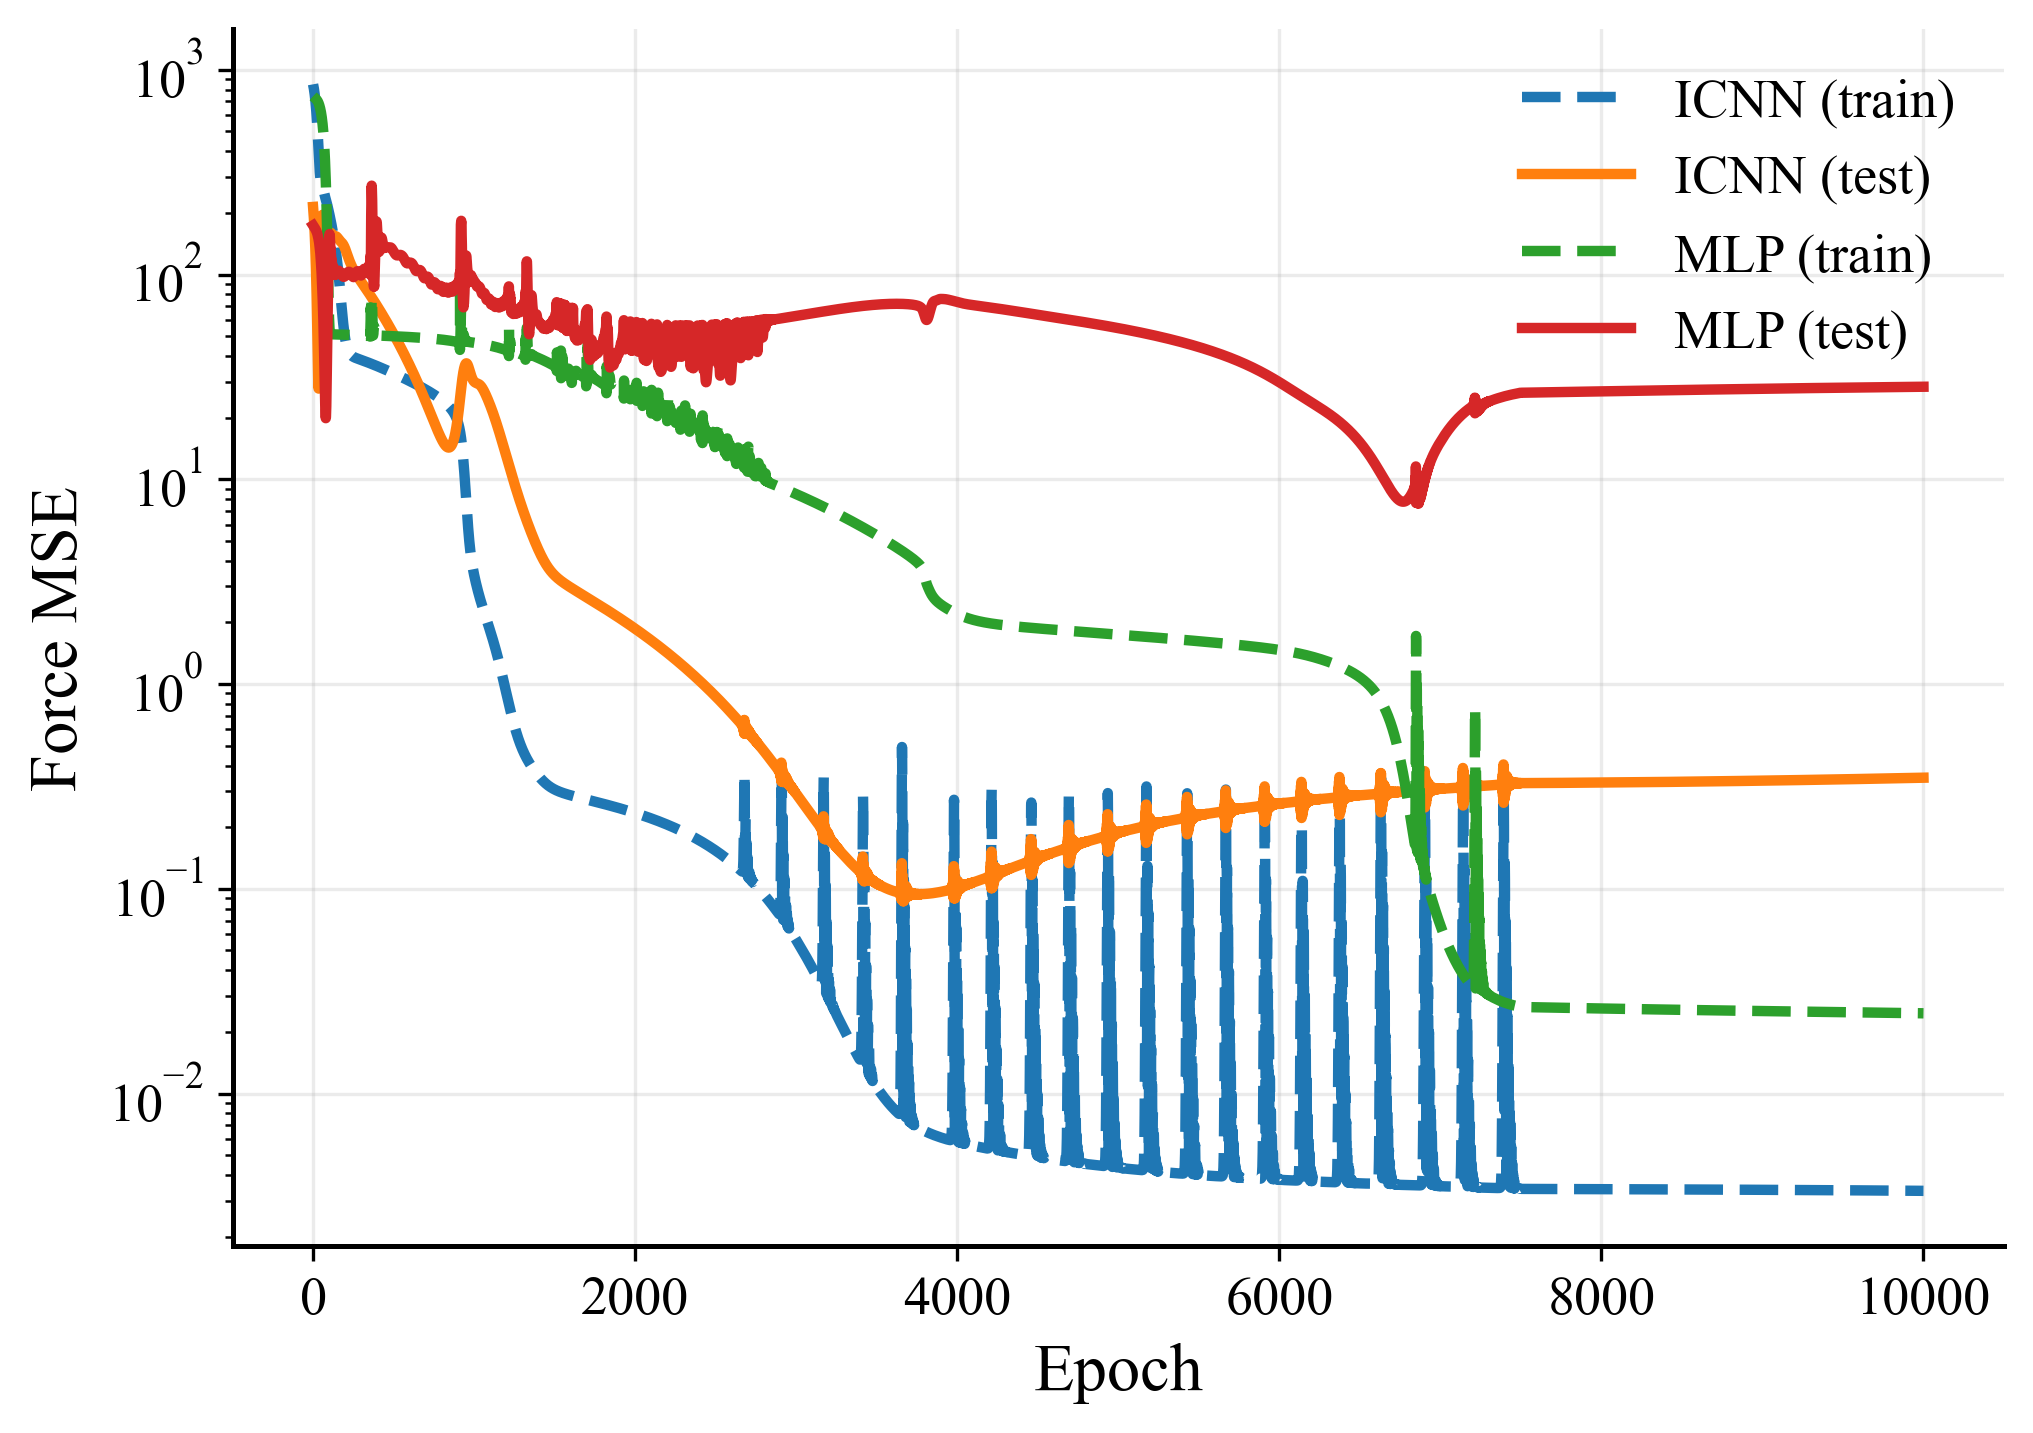

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# GLOBAL STYLE (publication quality)
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "lines.linewidth": 2,
    "axes.linewidth": 1.2,
    "grid.alpha": 0.25,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,   # editable text in Illustrator
    "ps.fonttype": 42,
})

# -----------------------------
# Load saved results
# -----------------------------
data_icnn = np.load("ablation_outputs/cases/energy_baseline_plus_icnn_L2.npz")
data_mlp  = np.load("ablation_outputs/cases/energy_baseline_plus_mlp_L2.npz")

# -----------------------------
# Extract data
# -----------------------------
x = data_icnn["pulled_node_x"]

y_true = data_icnn["force_truth"]
train_mask = data_icnn["train_mask"].astype(bool)
test_mask = data_icnn["test_mask"].astype(bool)

y_icnn = data_icnn["pred_force"]
y_mlp  = data_mlp["pred_force"]

train_loss_icnn = data_icnn["train_hist"]
test_loss_icnn  = data_icnn["test_hist"]

train_loss_mlp = data_mlp["train_hist"]
test_loss_mlp  = data_mlp["test_hist"]

# scale
scale = 10.0
y_true /= scale
y_icnn /= scale
y_mlp  /= scale

# scale loss by scale^2
train_loss_icnn /= scale**2
test_loss_icnn  /= scale**2
train_loss_mlp /= scale**2
test_loss_mlp  /= scale**2


# =============================
# 1) FORCE–DISPLACEMENT PLOT
# =============================
fig, ax = plt.subplots(figsize=(7, 5))

# Ground truth
ax.plot(
    x[train_mask],
    y_true[train_mask],
    "o",
    color="black",
    markersize=6,
    label="Ground truth (train)",
)

ax.plot(
    x[test_mask],
    y_true[test_mask],
    "o",
    markerfacecolor="none",
    markeredgecolor="black",
    markersize=6,
    label="Ground truth (test)",
)

# ICNN
ax.plot(
    x,
    y_icnn,
    linestyle="-",
    linewidth=2.5,
    label="ICNN",
)

# MLP
ax.plot(
    x,
    y_mlp,
    linestyle="--",
    linewidth=2.5,
    label="MLP",
)

ax.set_xlabel("Displacement (m)")
ax.set_ylabel("Force (N)")
# ax.set_title("Force (N)–Displacement (m) Comparison")

ax.grid(True)
ax.legend(frameon=False)

# clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# 🔥 Save as PDF (vector)
plt.savefig("force_displacement_icnn_vs_mlp.pdf", bbox_inches="tight")
plt.savefig("force_displacement_icnn_vs_mlp.png")  # optional

plt.show()


# =============================
# 2) LOSS CURVES PLOT
# =============================
fig, ax = plt.subplots(figsize=(7, 5))

# ICNN
ax.plot(
    train_loss_icnn,
    linestyle="--",
    linewidth=2.5,
    label="ICNN (train)",
)

ax.plot(
    test_loss_icnn,
    linestyle="-",
    linewidth=2.5,
    label="ICNN (test)",
)

# MLP
ax.plot(
    train_loss_mlp,
    linestyle="--",
    linewidth=2.5,
    label="MLP (train)",
)

ax.plot(
    test_loss_mlp,
    linestyle="-",
    linewidth=2.5,
    label="MLP (test)",
)

ax.set_yscale("log")

ax.set_xlabel("Epoch")
ax.set_ylabel("Force MSE")
# ax.set_title("Training vs Testing Loss")

ax.grid(True)
ax.legend(frameon=False)

# clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# 🔥 Save as PDF
plt.savefig("loss_curves_icnn_vs_mlp.pdf", bbox_inches="tight")
plt.savefig("loss_curves_icnn_vs_mlp.png")

plt.show()